# BFCL Cache Behavior Analysis
Comparative analysis of prompt caching across providers and implementations.
Shows hit rates, token composition, cached-token growth, and block alignment per turn.

In [1]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
# Add one entry per run you want to compare.
# result_dir: path to the result/ folder for that run
# date:       the timestamp subfolder inside result/{provider}/
# label:      display name used in all charts

from pathlib import Path
BASE = Path(".")   # notebook is in the BFCL root

RUNS = [
    {
        "label": "SambaNova 2026-06-10",
        "result_dir": BASE / "result",
        "date": "2026-06-10T14:00:15",
    },
    {
        "label": "Fireworks 2026-06-11",
        "result_dir": BASE / "result",
        "date": "2026-06-11T18:43:07",
    },
]

# Categories to include in per-turn charts (leave empty [] for all found)
CATEGORIES_FOCUS = ["multi_turn_base", "multi_turn_long_context"]

# Block sizes to probe in the alignment chart
BLOCK_SIZES = [32, 64, 128, 256, 512, 1024, 4096]
# ──────────────────────────────────────────────────────────────────────────────

In [5]:
import json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import defaultdict

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})


# ── helpers ───────────────────────────────────────────────────────────────────

def flatten(val):
    if isinstance(val, list):
        return sum(flatten(v) for v in val)
    return int(val or 0)


def load_entries(path):
    entries = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return entries


def per_turn_stats(entries):
    """Returns list of dicts, one per turn index, with avg input/cached/output/n."""
    max_turns = max((len(e.get("input_token_count", [])) for e in entries), default=0)
    rows = []
    for t in range(max_turns):
        inputs, cached, outputs = [], [], []
        for e in entries:
            ic = e.get("input_token_count", [])
            cc = e.get("cached_token_count", [])
            oc = e.get("output_token_count", [])
            if t < len(ic):
                inputs.append(flatten(ic[t]))
                cached.append(flatten(cc[t]) if t < len(cc) else 0)
                outputs.append(flatten(oc[t]) if t < len(oc) else 0)
        if inputs:
            avg_i = sum(inputs) / len(inputs)
            avg_c = sum(cached) / len(cached)
            avg_o = sum(outputs) / len(outputs)
            rows.append({
                "turn": t,
                "avg_input": avg_i,
                "avg_cached": avg_c,
                "avg_output": avg_o,
                "avg_new": avg_i - avg_c,
                "hit_rate": avg_c / avg_i * 100 if avg_i > 0 else 0,
                "n": len(inputs),
            })
    return rows


def all_step_cached(entries):
    """Flat list of every per-step cached token count (>0 only)."""
    vals = []
    for e in entries:
        ic = e.get("input_token_count", [])
        cc = e.get("cached_token_count", [])
        for t in range(len(ic)):
            steps_i = ic[t] if isinstance(ic[t], list) else [ic[t]]
            steps_c = cc[t] if (t < len(cc) and isinstance(cc[t], list)) else ([cc[t]] if t < len(cc) else [0] * len(steps_i))
            for ti, tc in zip(steps_i, steps_c):
                if int(tc or 0) > 0:
                    vals.append(int(tc))
    return vals


# ── load all runs ─────────────────────────────────────────────────────────────

DATA = []   # list of {label, category, entries, turn_stats}

for run in RUNS:
    result_dir = Path(run["result_dir"])
    date = run["date"]
    label = run["label"]
    for provider_dir in sorted(result_dir.iterdir()):
        date_dir = provider_dir / date
        if not date_dir.exists():
            continue
        for model_dir in sorted(date_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            for result_file in sorted(model_dir.glob("*_result.json")):
                stem = result_file.stem
                category = stem.replace("BFCL_v3_", "").replace("_result", "")
                if CATEGORIES_FOCUS and category not in CATEGORIES_FOCUS:
                    continue
                entries = load_entries(result_file)
                if not entries:
                    continue
                DATA.append({
                    "label": label,
                    "category": category,
                    "entries": entries,
                    "turn_stats": per_turn_stats(entries),
                    "step_cached": all_step_cached(entries),
                })

categories = sorted({d["category"] for d in DATA})
run_labels = [r["label"] for r in RUNS]

## 1 · Overall cache hit rate by provider × category

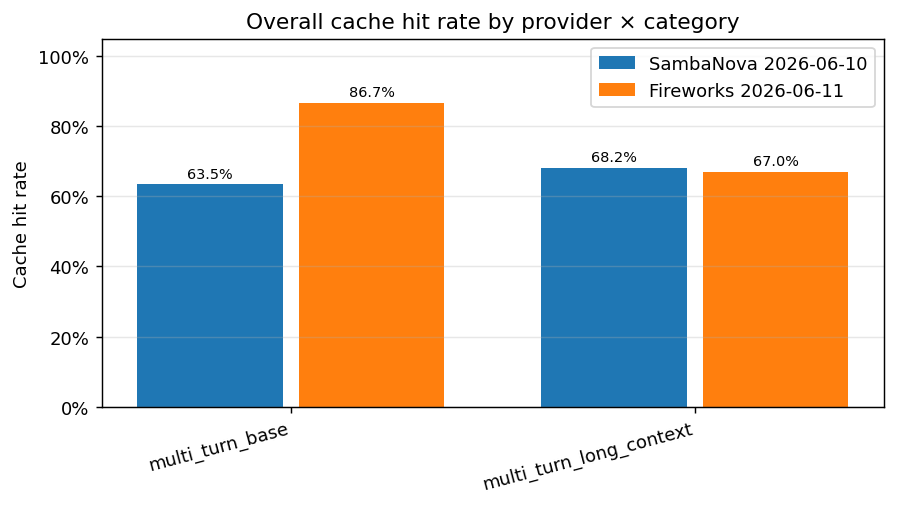

In [6]:
def overall_hit_rate(d):
    total_i = sum(flatten(e.get("input_token_count", 0)) for e in d["entries"])
    total_c = sum(flatten(e.get("cached_token_count", 0)) for e in d["entries"])
    return total_c / total_i * 100 if total_i > 0 else 0

x = np.arange(len(categories))
width = 0.8 / max(len(run_labels), 1)
fig, ax = plt.subplots(figsize=(max(7, len(categories) * 2), 4))

for i, lbl in enumerate(run_labels):
    rates = []
    for cat in categories:
        match = [d for d in DATA if d["label"] == lbl and d["category"] == cat]
        rates.append(overall_hit_rate(match[0]) if match else 0)
    offset = (i - len(run_labels) / 2 + 0.5) * width
    bars = ax.bar(x + offset, rates, width * 0.9, label=lbl)
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 105)
ax.set_ylabel("Cache hit rate")
ax.set_title("Overall cache hit rate by provider × category")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2 · Cache hit rate per turn  
Shows how hit rate evolves as the conversation grows.

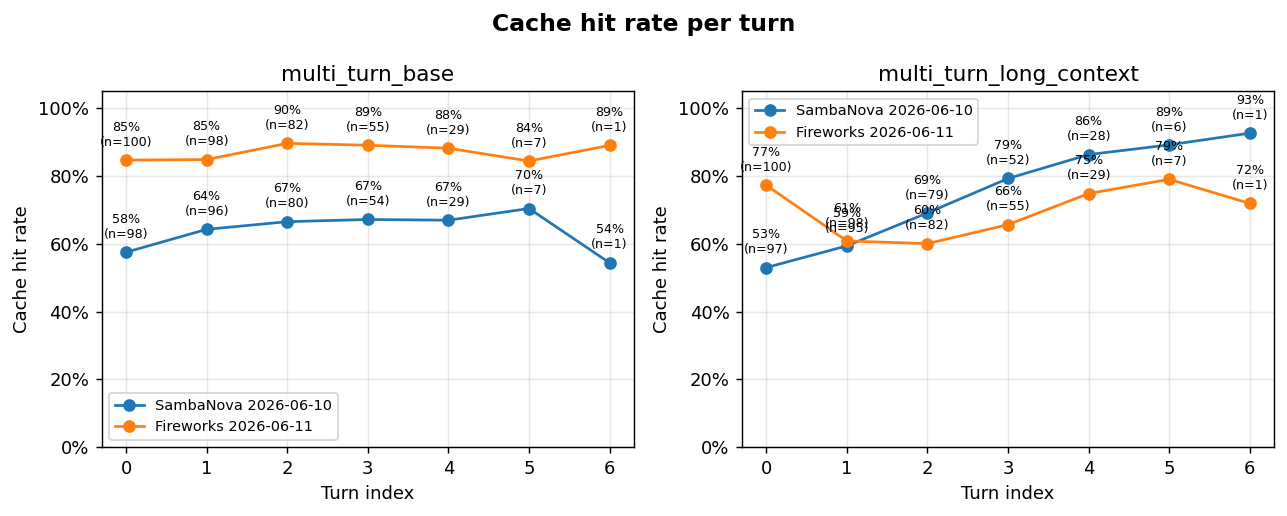

In [7]:
ncols = min(len(categories), 3)
nrows = math.ceil(len(categories) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for idx, cat in enumerate(categories):
    ax = axes[idx // ncols][idx % ncols]
    for d in DATA:
        if d["category"] != cat:
            continue
        ts = d["turn_stats"]
        turns = [r["turn"] for r in ts]
        rates = [r["hit_rate"] for r in ts]
        ns    = [r["n"] for r in ts]
        ax.plot(turns, rates, marker="o", label=d["label"])
        for t, r, n in zip(turns, rates, ns):
            ax.annotate(f"{r:.0f}%\n(n={n})", (t, r), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel("Turn index")
    ax.set_ylabel("Cache hit rate")
    ax.set_title(cat)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for idx in range(len(categories), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Cache hit rate per turn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3 · Cached token growth per turn  
Growing cached counts across turns = session-affine KV reuse.  
Flat / non-growing = no per-conversation KV persistence.

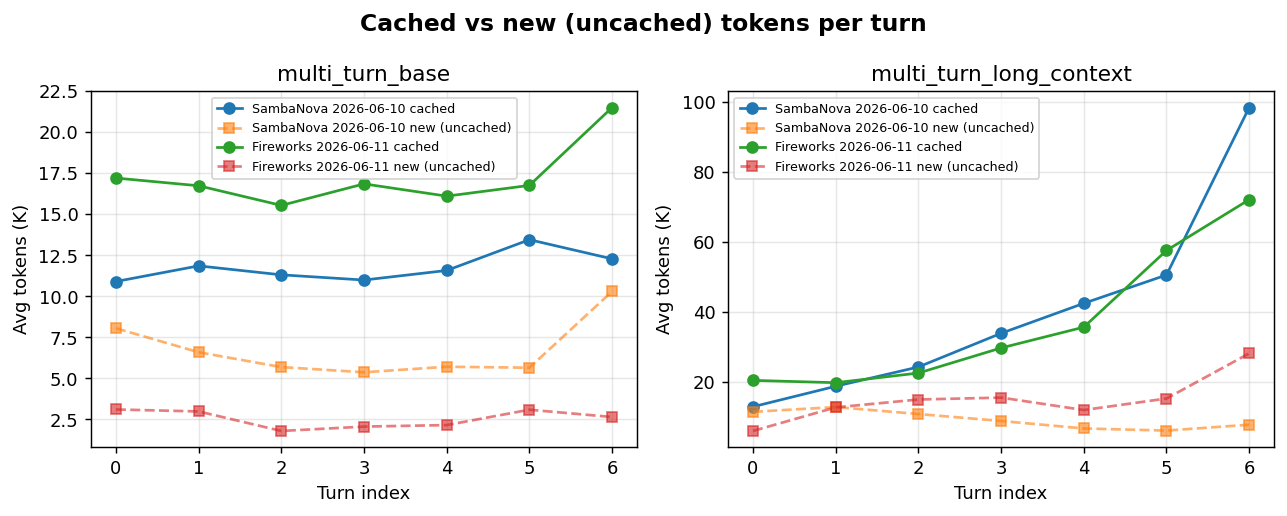

In [8]:
ncols = min(len(categories), 3)
nrows = math.ceil(len(categories) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for idx, cat in enumerate(categories):
    ax = axes[idx // ncols][idx % ncols]
    for d in DATA:
        if d["category"] != cat:
            continue
        ts = d["turn_stats"]
        turns  = [r["turn"]       for r in ts]
        cached = [r["avg_cached"] / 1000 for r in ts]
        new    = [r["avg_new"]    / 1000 for r in ts]
        ax.plot(turns, cached, marker="o", label=f"{d['label']} cached")
        ax.plot(turns, new,    marker="s", linestyle="--",
                label=f"{d['label']} new (uncached)", alpha=0.6)
    ax.set_xlabel("Turn index")
    ax.set_ylabel("Avg tokens (K)")
    ax.set_title(cat)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for idx in range(len(categories), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Cached vs new (uncached) tokens per turn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 · Token composition per turn (stacked bar)
Cached (green) + new uncached (orange) = total input per turn.

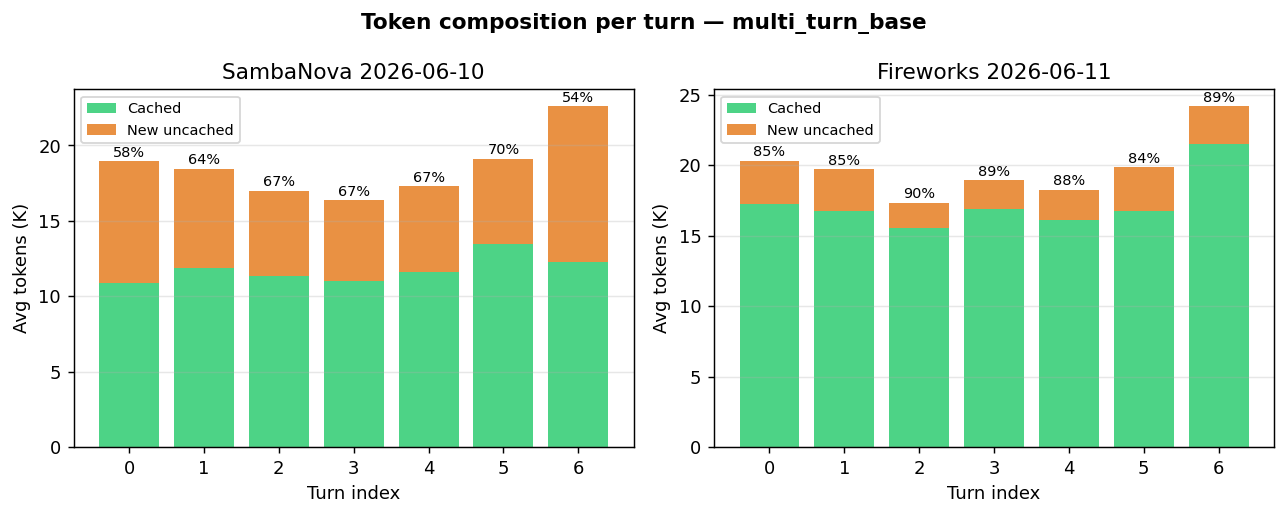

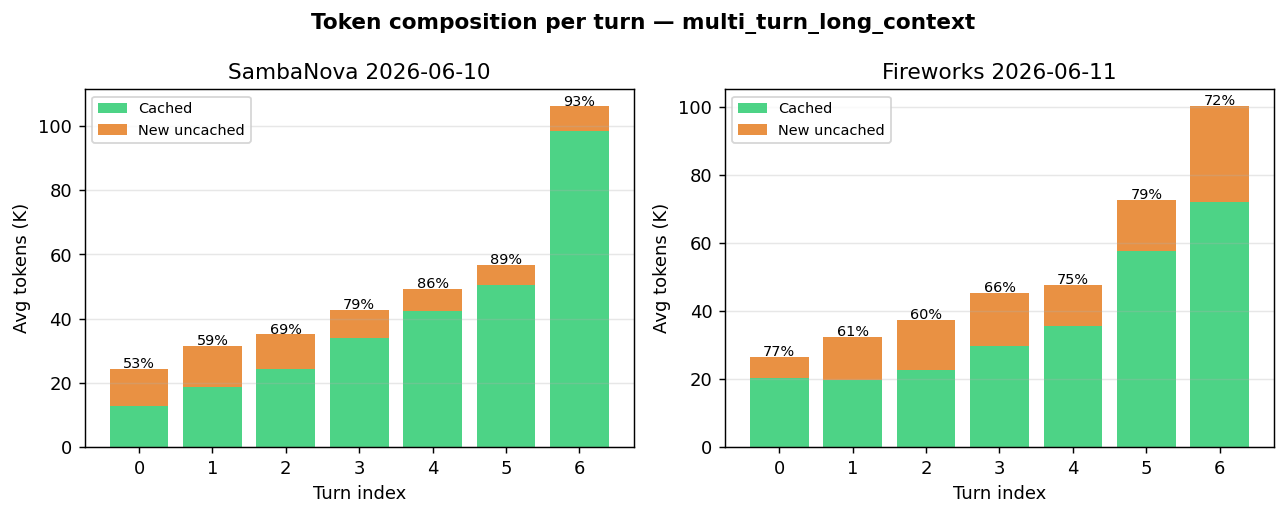

In [9]:
for cat in categories:
    cat_data = [d for d in DATA if d["category"] == cat]
    if not cat_data:
        continue
    max_turns = max(len(d["turn_stats"]) for d in cat_data)
    n_runs = len(cat_data)
    fig, axes = plt.subplots(1, n_runs, figsize=(5 * n_runs, 4), squeeze=False)

    for col, d in enumerate(cat_data):
        ax = axes[0][col]
        ts = d["turn_stats"]
        turns  = [r["turn"]       for r in ts]
        cached = [r["avg_cached"] / 1000 for r in ts]
        new    = [r["avg_new"]    / 1000 for r in ts]
        ax.bar(turns, cached, label="Cached",      color="#2ecc71", alpha=0.85)
        ax.bar(turns, new,    label="New uncached", color="#e67e22", alpha=0.85,
               bottom=cached)
        for t, c, nw in zip(turns, cached, new):
            total = c + nw
            pct = c / total * 100 if total > 0 else 0
            ax.text(t, total + 0.3, f"{pct:.0f}%", ha="center", fontsize=8)
        ax.set_xlabel("Turn index")
        ax.set_ylabel("Avg tokens (K)")
        ax.set_title(f"{d['label']}")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(f"Token composition per turn — {cat}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 5 · Block alignment analysis  
For each provider, checks what % of cached-token values are exact multiples of each block size.  
A spike near 100% reveals the physical KV block granularity.

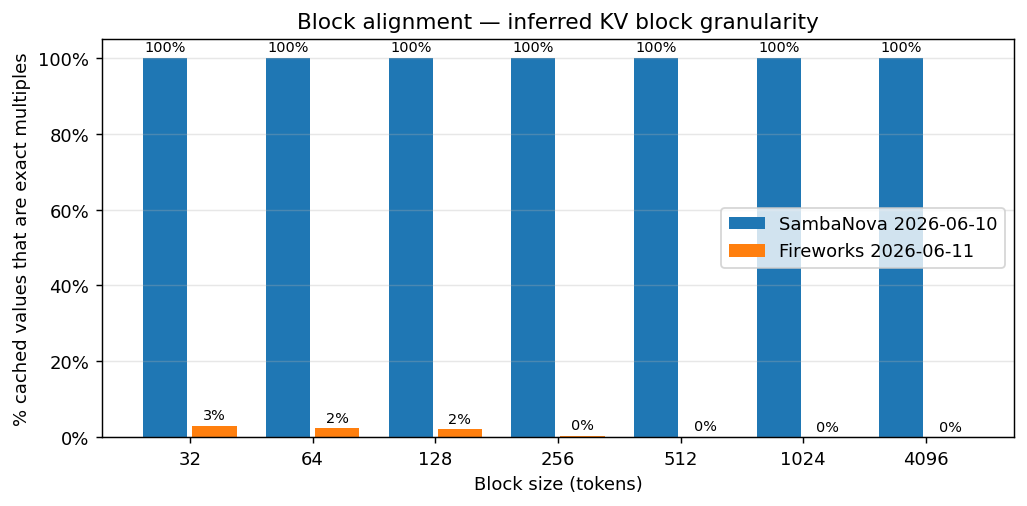


GCD of all cached values per provider:
  SambaNova 2026-06-10: GCD = 4096
  Fireworks 2026-06-11: GCD = 1


In [10]:
# Aggregate step-level cached values per run label (across all categories)
by_label = defaultdict(list)
for d in DATA:
    by_label[d["label"]].extend(d["step_cached"])

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(BLOCK_SIZES))
width = 0.8 / max(len(run_labels), 1)

for i, lbl in enumerate(run_labels):
    vals = by_label[lbl]
    if not vals:
        continue
    pcts = [sum(1 for v in vals if v % b == 0) / len(vals) * 100 for b in BLOCK_SIZES]
    offset = (i - len(run_labels) / 2 + 0.5) * width
    bars = ax.bar(x + offset, pcts, width * 0.9, label=lbl)
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in BLOCK_SIZES])
ax.set_xlabel("Block size (tokens)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("% cached values that are exact multiples")
ax.set_title("Block alignment — inferred KV block granularity")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print GCD per label
print("\nGCD of all cached values per provider:")
for lbl in run_labels:
    vals = by_label[lbl]
    if vals:
        g = vals[0]
        for v in vals[1:]:
            g = math.gcd(g, v)
        print(f"  {lbl}: GCD = {g}")

## 6 · Cached token remainder distribution  
Histogram of `cached_tokens mod block_size` for the most likely block size.  
Spike at 0 = aligned caching. Flat = no alignment (token-level exact match).

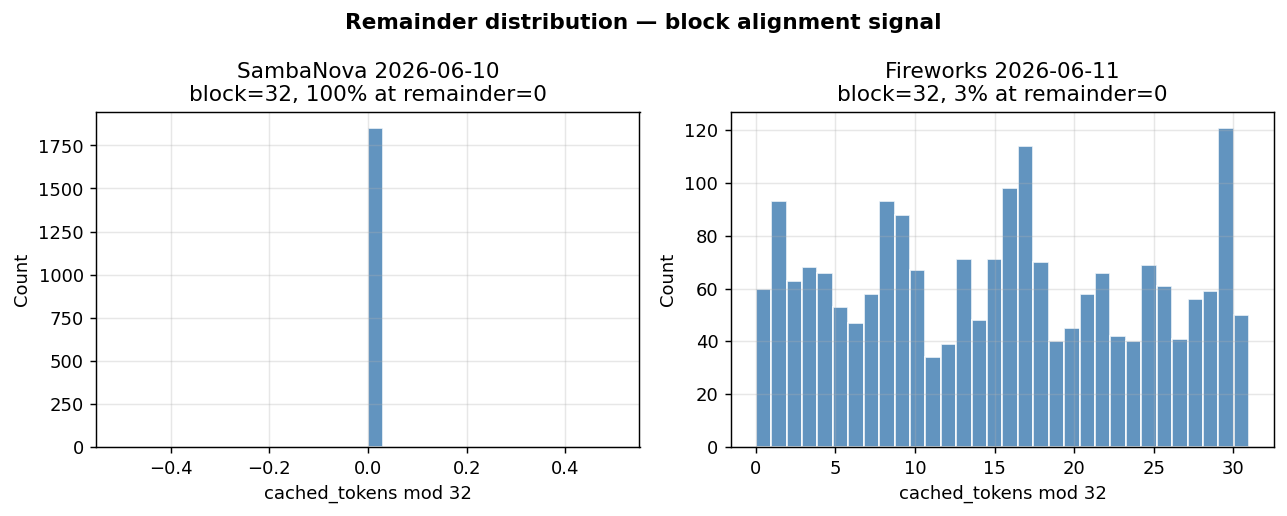

In [11]:
# Auto-pick the block size with the highest alignment % for each label,
# fallback to largest candidate.

fig, axes = plt.subplots(1, len(run_labels), figsize=(5 * len(run_labels), 4), squeeze=False)

for col, lbl in enumerate(run_labels):
    ax = axes[0][col]
    vals = by_label[lbl]
    if not vals:
        ax.set_title(f"{lbl}\n(no data)")
        continue

    best_block = max(BLOCK_SIZES,
                     key=lambda b: sum(1 for v in vals if v % b == 0))
    remainders = [v % best_block for v in vals]
    zero_pct = remainders.count(0) / len(remainders) * 100

    ax.hist(remainders, bins=min(50, best_block), color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_xlabel(f"cached_tokens mod {best_block}")
    ax.set_ylabel("Count")
    ax.set_title(f"{lbl}\nblock={best_block}, {zero_pct:.0f}% at remainder=0")
    ax.grid(alpha=0.3)

fig.suptitle("Remainder distribution — block alignment signal", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 7 · Summary table

In [12]:
print(f"{'Provider':<28} {'Category':<30} {'Input(M)':>9} {'Output(M)':>9} {'Cached(M)':>10} {'Hit %':>7} {'Entries':>8}")
print("-" * 100)
for d in DATA:
    entries = d["entries"]
    total_i = sum(flatten(e.get("input_token_count",  0)) for e in entries)
    total_o = sum(flatten(e.get("output_token_count", 0)) for e in entries)
    total_c = sum(flatten(e.get("cached_token_count", 0)) for e in entries)
    hit = total_c / total_i * 100 if total_i > 0 else 0
    print(f"{d['label']:<28} {d['category']:<30} {total_i/1e6:>9.2f} {total_o/1e6:>9.2f} {total_c/1e6:>10.2f} {hit:>6.1f}% {len(entries):>8}")

Provider                     Category                        Input(M) Output(M)  Cached(M)   Hit %  Entries
----------------------------------------------------------------------------------------------------
SambaNova 2026-06-10         multi_turn_base                     6.53      0.14       4.15   63.5%      100
SambaNova 2026-06-10         multi_turn_long_context            12.18      0.18       8.30   68.2%      100
Fireworks 2026-06-11         multi_turn_base                     7.12      0.14       6.17   86.7%      100
Fireworks 2026-06-11         multi_turn_long_context            13.38      0.19       8.97   67.0%      100
